# **Classification Fine Tuning**

## **Prepare Dataset**
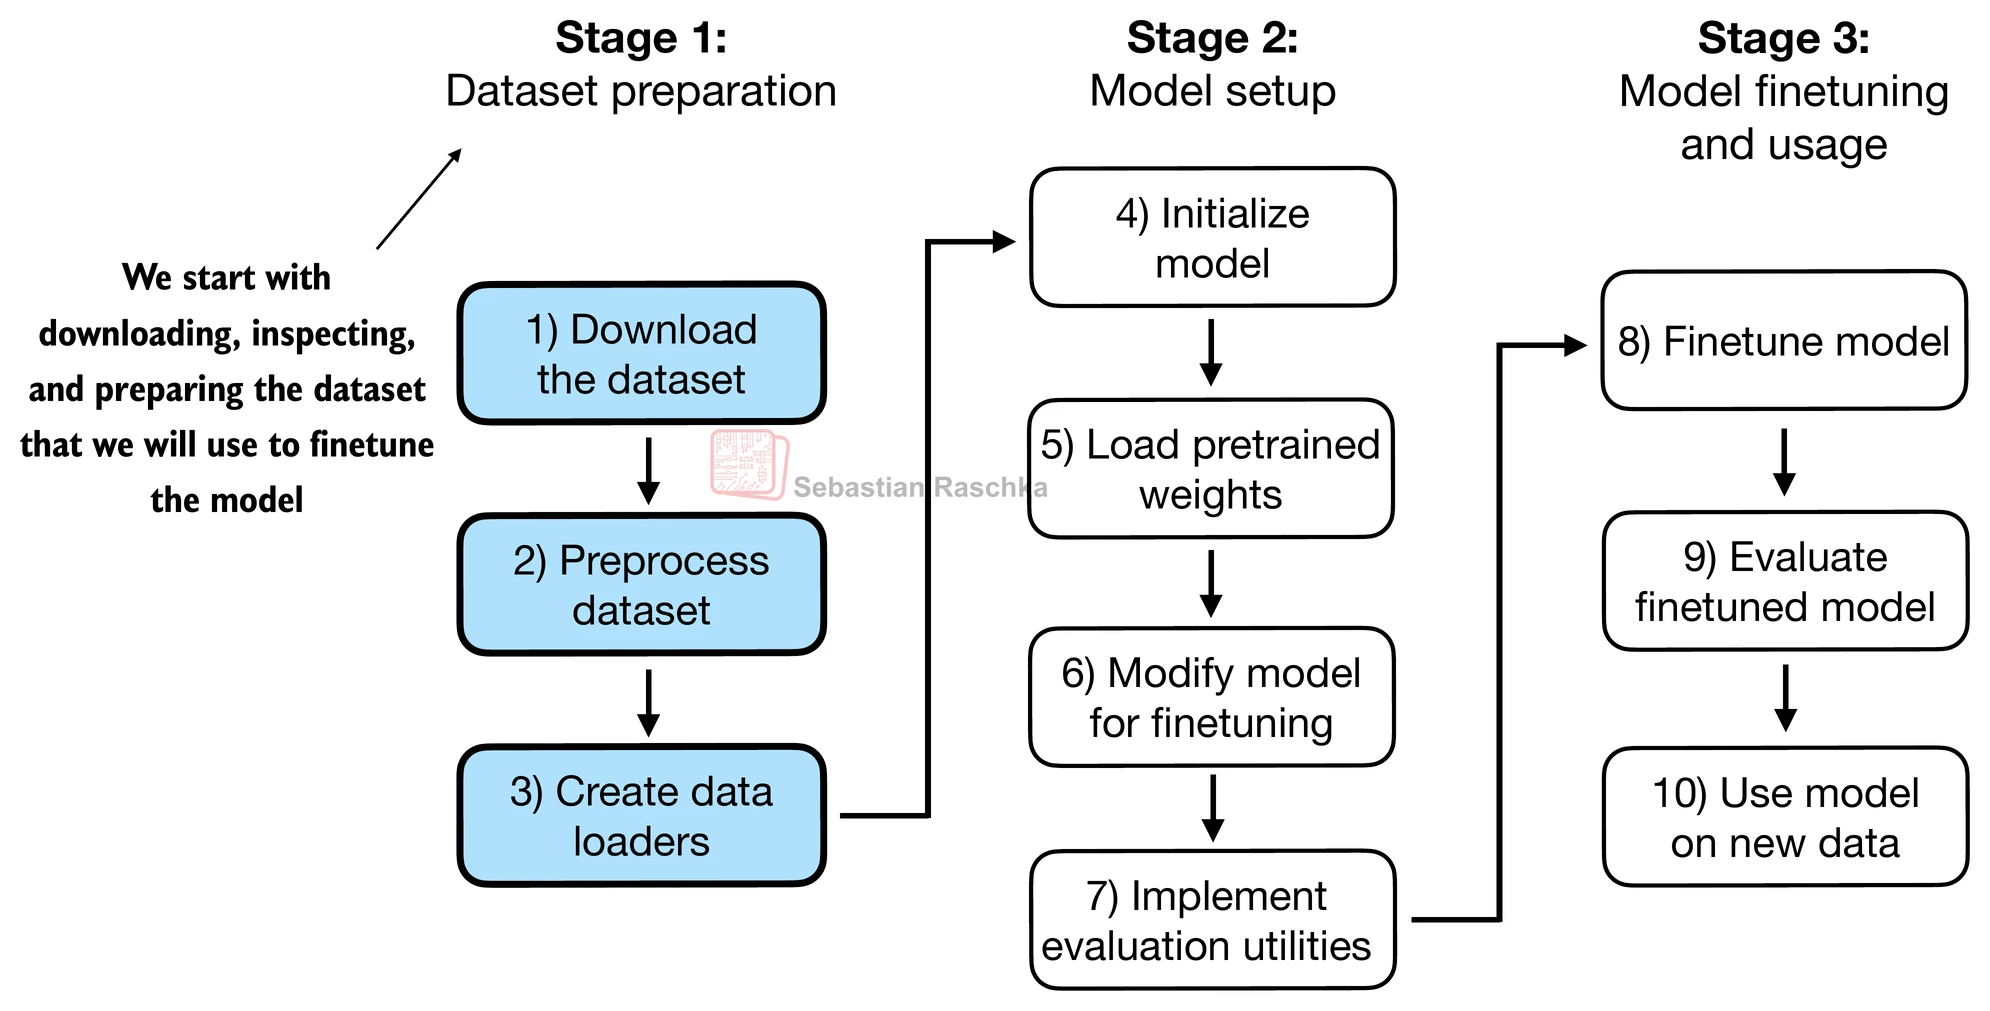

In [2]:
import pandas as pd

data_file_path = r"..\sms_spam_collection\SMSSpamCollection.tsv"

df = pd.read_csv(
    data_file_path, sep="\t", header = None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


There are significantly more non spam than spam in the data therefore we need to undersamples and make it balanced 

In [ ]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]

    #randomly sample ham messages to match the number of spam messages
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    )

    #combine the samp ham messages with spam messages 
    balanced_df = pd.concat([
        ham_subset,
        df[df["Label"] == "spam"]
    ])

    return balanced_df 

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


Similar to converting text into tokens we need to do the same but convert ham -> 0 and spam -> 1. (String-> Integer)

In [5]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [7]:
from Classif_Fine_tuning import random_split

train_df, val_df, test_df = random_split(balanced_df, 0.7, 0.1)

#save them
train_df.to_csv("train.csv", index=None)
val_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)


## **Creating Data loaders**

previous we used a sliding window method where the numebr of token would be consistent for more efficient model training. However unlike before, you can't just split is as the text messages are different in length.

2 options:
1. truncate messages to shortest -> info loss = bad training
2. pad all messages to longest message -> using <|endoftext|> (token ID = 50256) as padding 
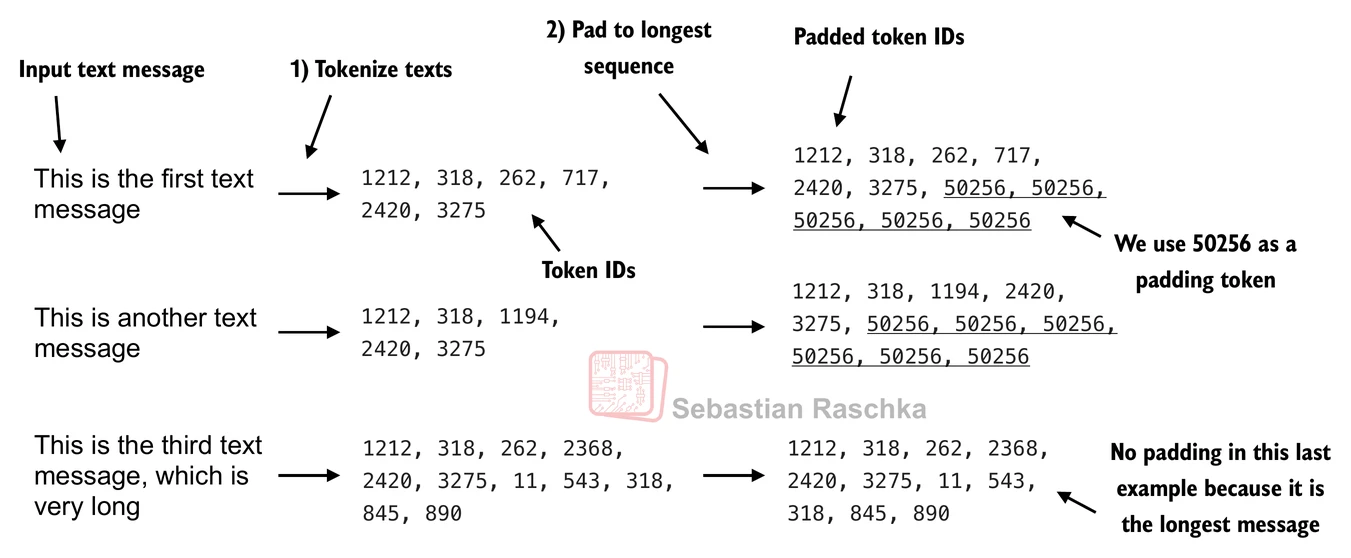

In [ ]:
from Classif_Fine_tuning import SpamDataset
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")

train_dataset = SpamDataset(
    csv_file = "train.csv",
    max_length = None,
    tokenizer = tokenizer
)

val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

print(train_dataset.max_length) 

120


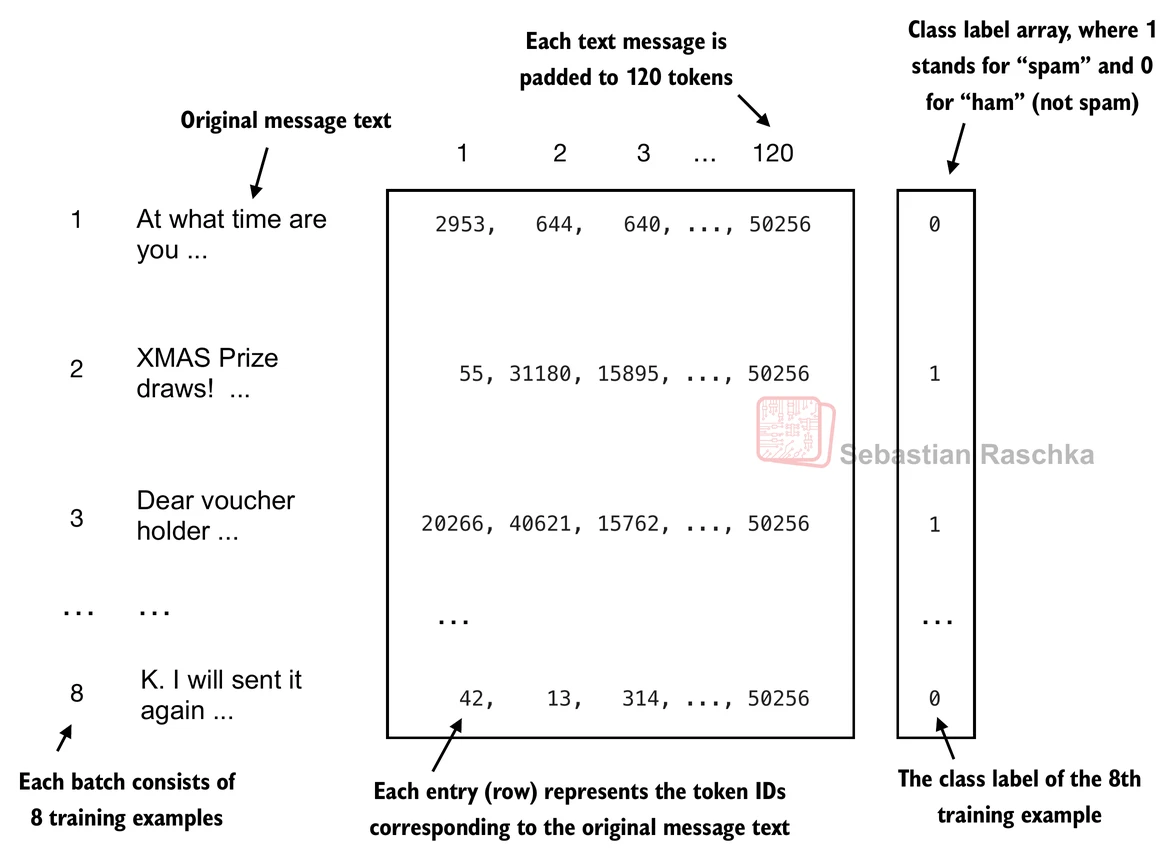

In [ ]:
from torch.utils.data import DataLoader
import torch

num_workers = 0 
batch_size = 8 #breaks data into batches 8 samples at a time
torch.manual_seed(123)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = num_workers,
    drop_last = True
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    num_workers = num_workers,
    drop_last = False
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    num_workers = num_workers,
    drop_last = False
)

print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape) #input batch (8,120) 8 samples 120 token each(max length)
print("Label batch dimensions", target_batch.shape) #only 8 since it is just the labels for the 8 samples

print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])
130 training batches
19 validation batches
38 test batches


## **Initializing Model with pretrained weights**

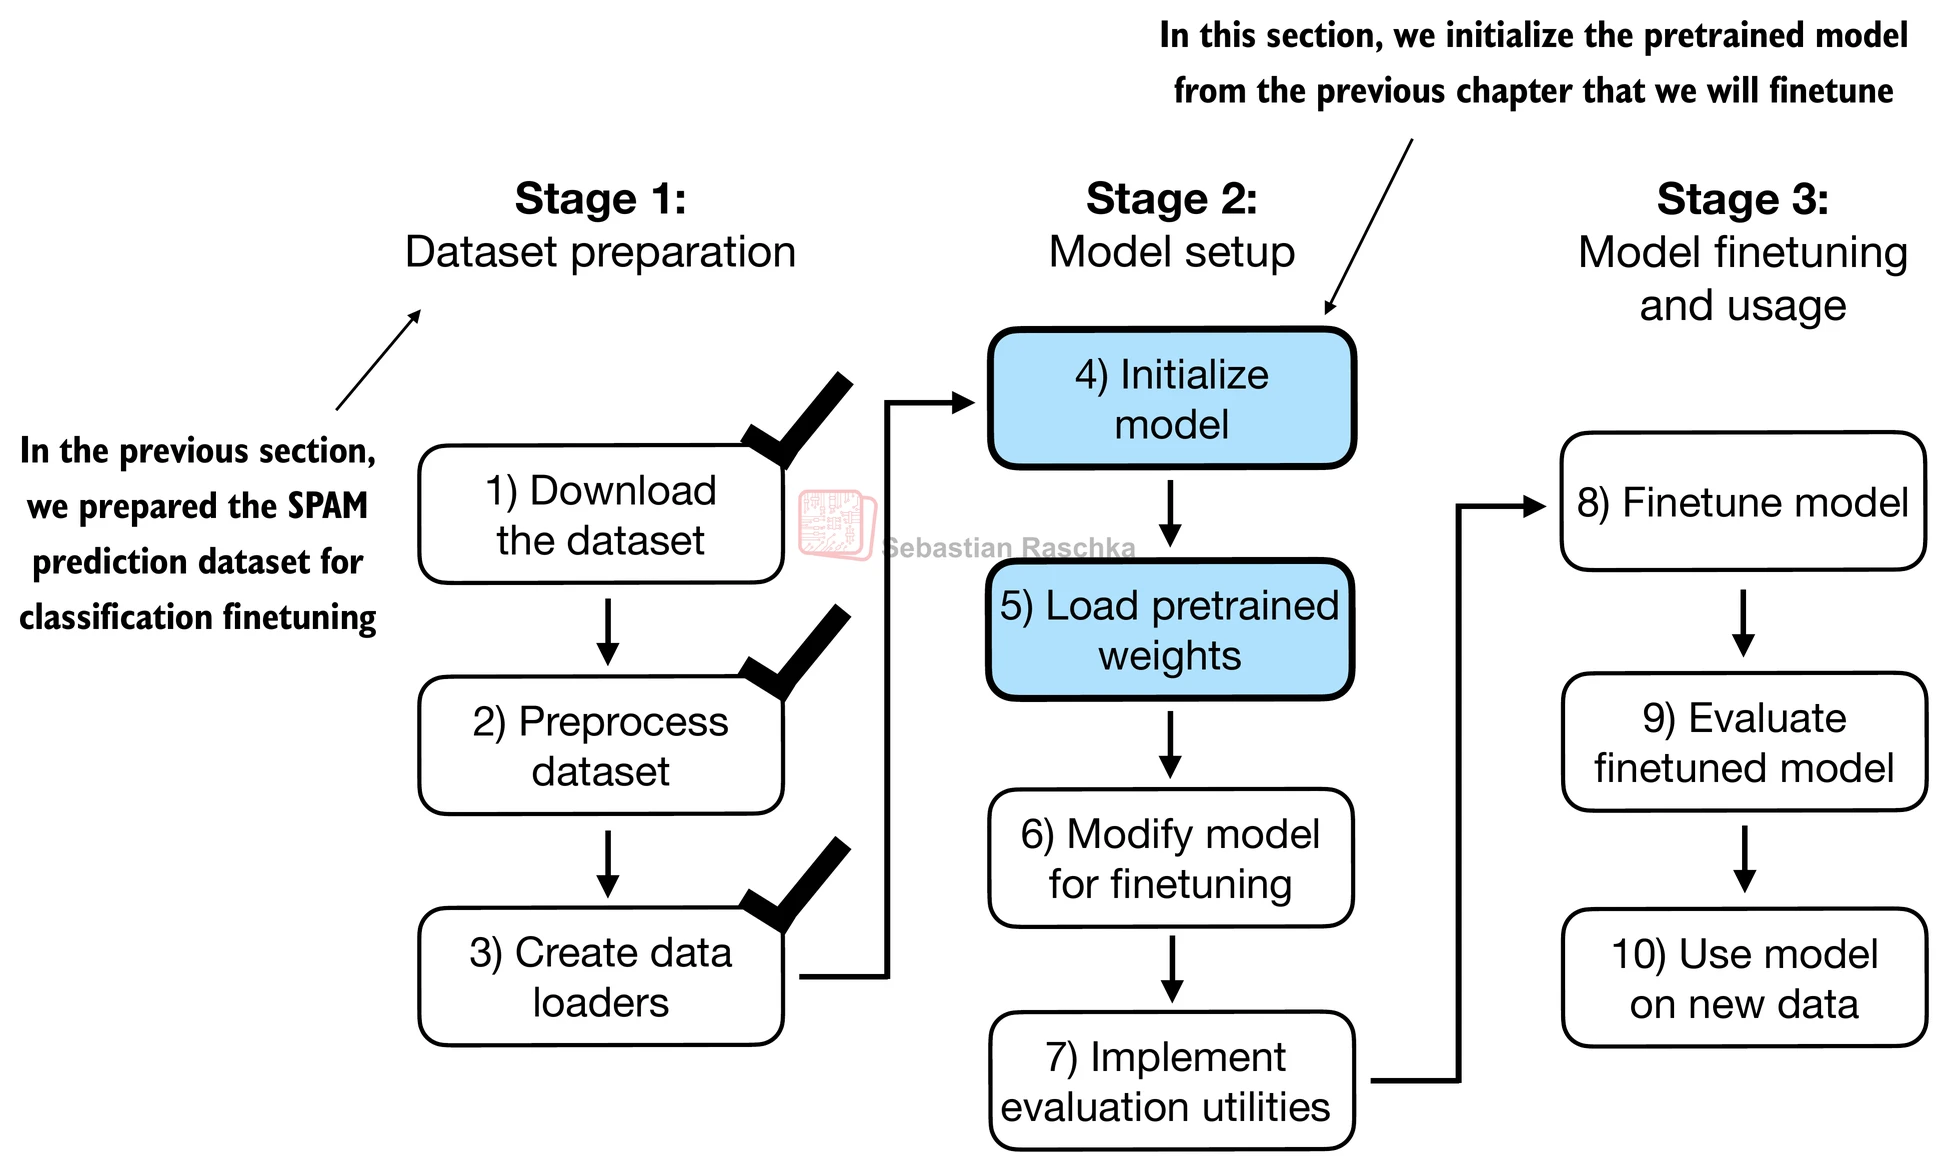

In [14]:
import sys
import os

sys.path.append('../Pretraining_on_unlabeled_data')

#ch 5 GPT model, loading weights 
from gpt_download import download_and_load_gpt2
from Pretraining import  load_weights_into_gpt, text_to_token_ids, token_ids_to_text

#ch4 function to generate text using a model
sys.path.append('../GPT_model')
from GPT_Model_architecture_class import generate_text_simple, GPTModel

In [12]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     
    "context_length": 1024,  
    "drop_rate": 0.0,        
    "qkv_bias": True         
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "num_layers": 12, "num_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [13]:
#getting the 124M in the string 
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size = model_size, models_dir ="gpt2")

#intializing and loading weights into our GPT model
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [17]:
text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(text_1, tokenizer),
    max_new_tokens = 15,
    context_size = BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


What if we try prompting before finetuning?

In [ ]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(text_2, tokenizer),
    max_new_tokens = 23,
    context_size = BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer)) # no it doesn't know the answer 

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


## **Classification Head**

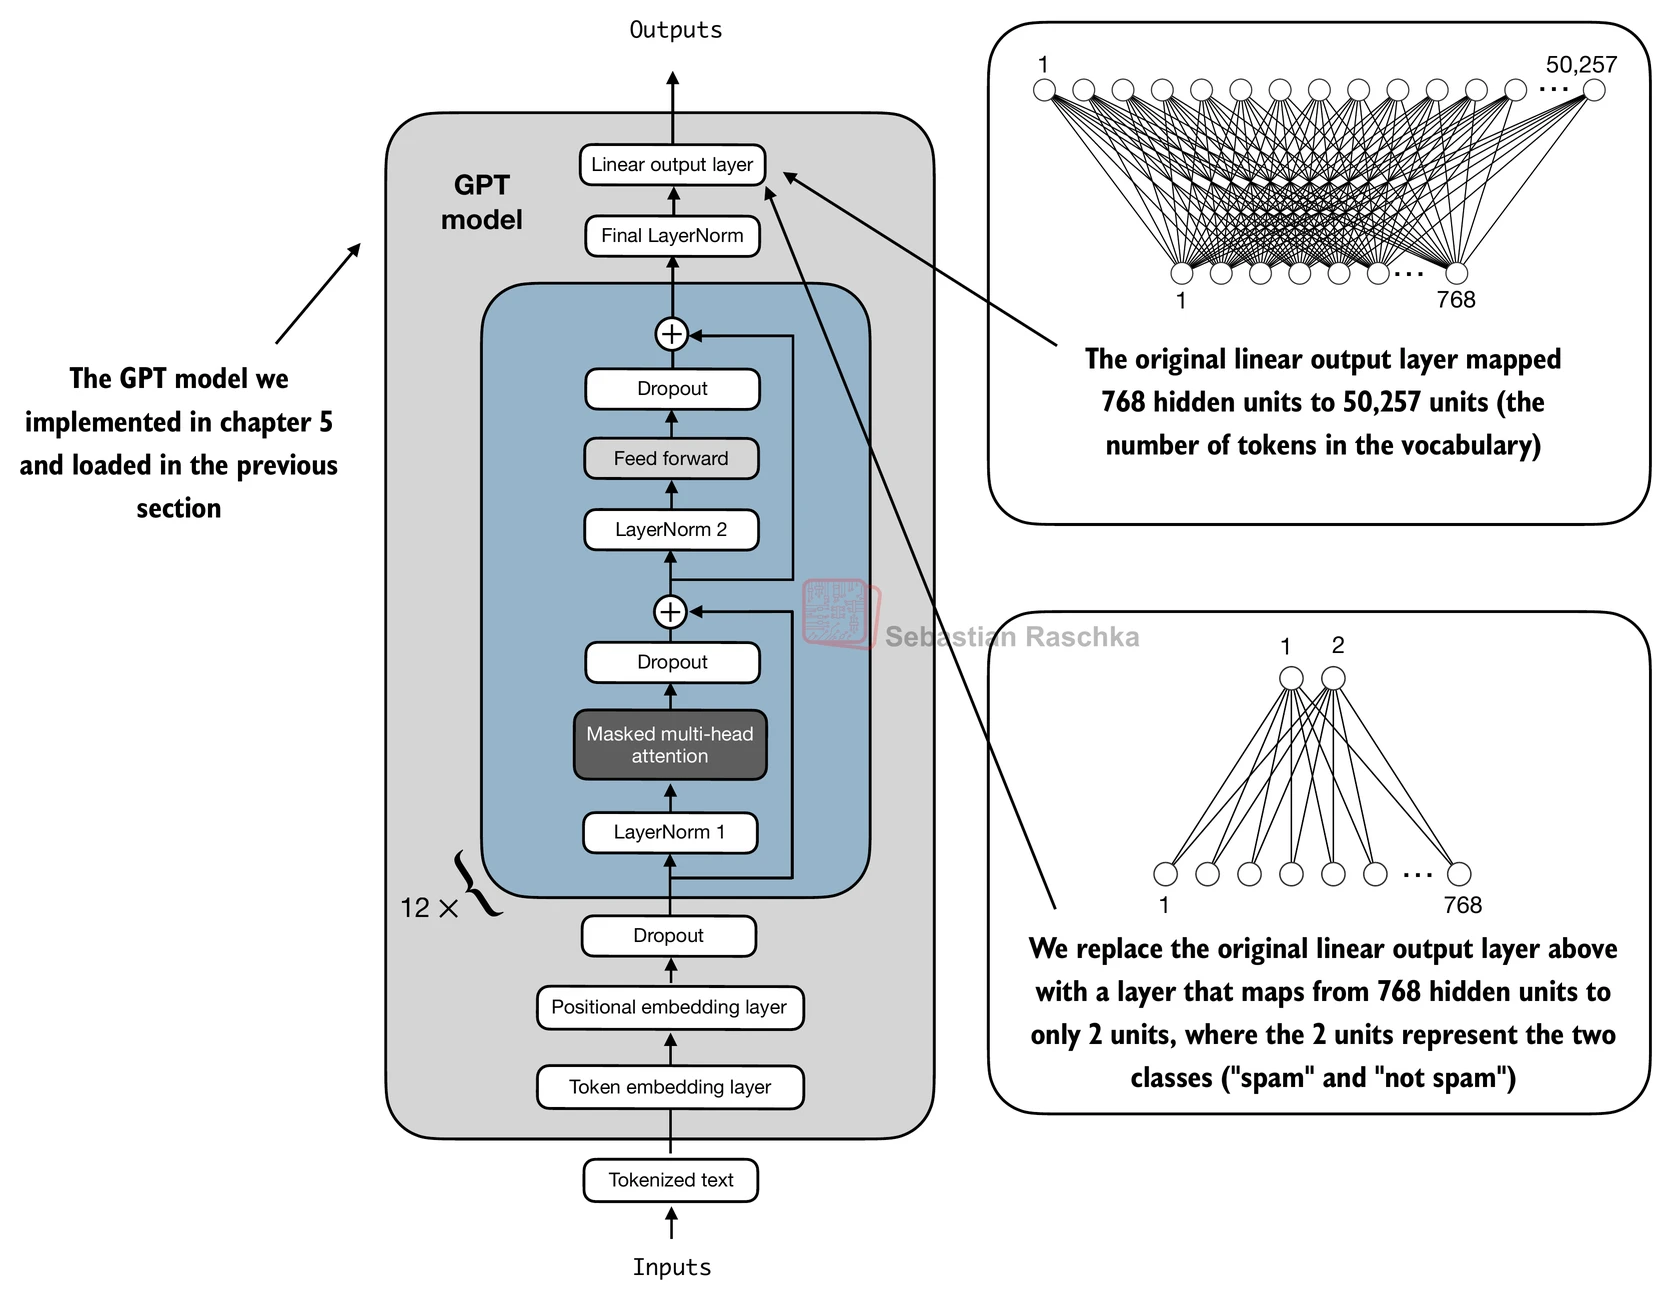
Rather than having the final output layer 50257(vocab size) it would just have 2 options either 0 or 1. 

In [ ]:
print(model) 
#output has 50257 features

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [26]:
#we lock the layer's weights so it doesn't update during training
for param in model.parameters():
    param.requires_grad = False

In [27]:
torch.manual_seed(123)
num_classes = 2

#swapping out the output head 
model.out_head = torch.nn.Linear(
    in_features = BASE_CONFIG["emb_dim"], #input features is the same as before 
    out_features = num_classes #2 outputs 
)


By freezing the other layers, only this new 2 output layer is trainable and ready to learn. As mentioned sometimes unfreezing other layers could make the model perform bettern.
 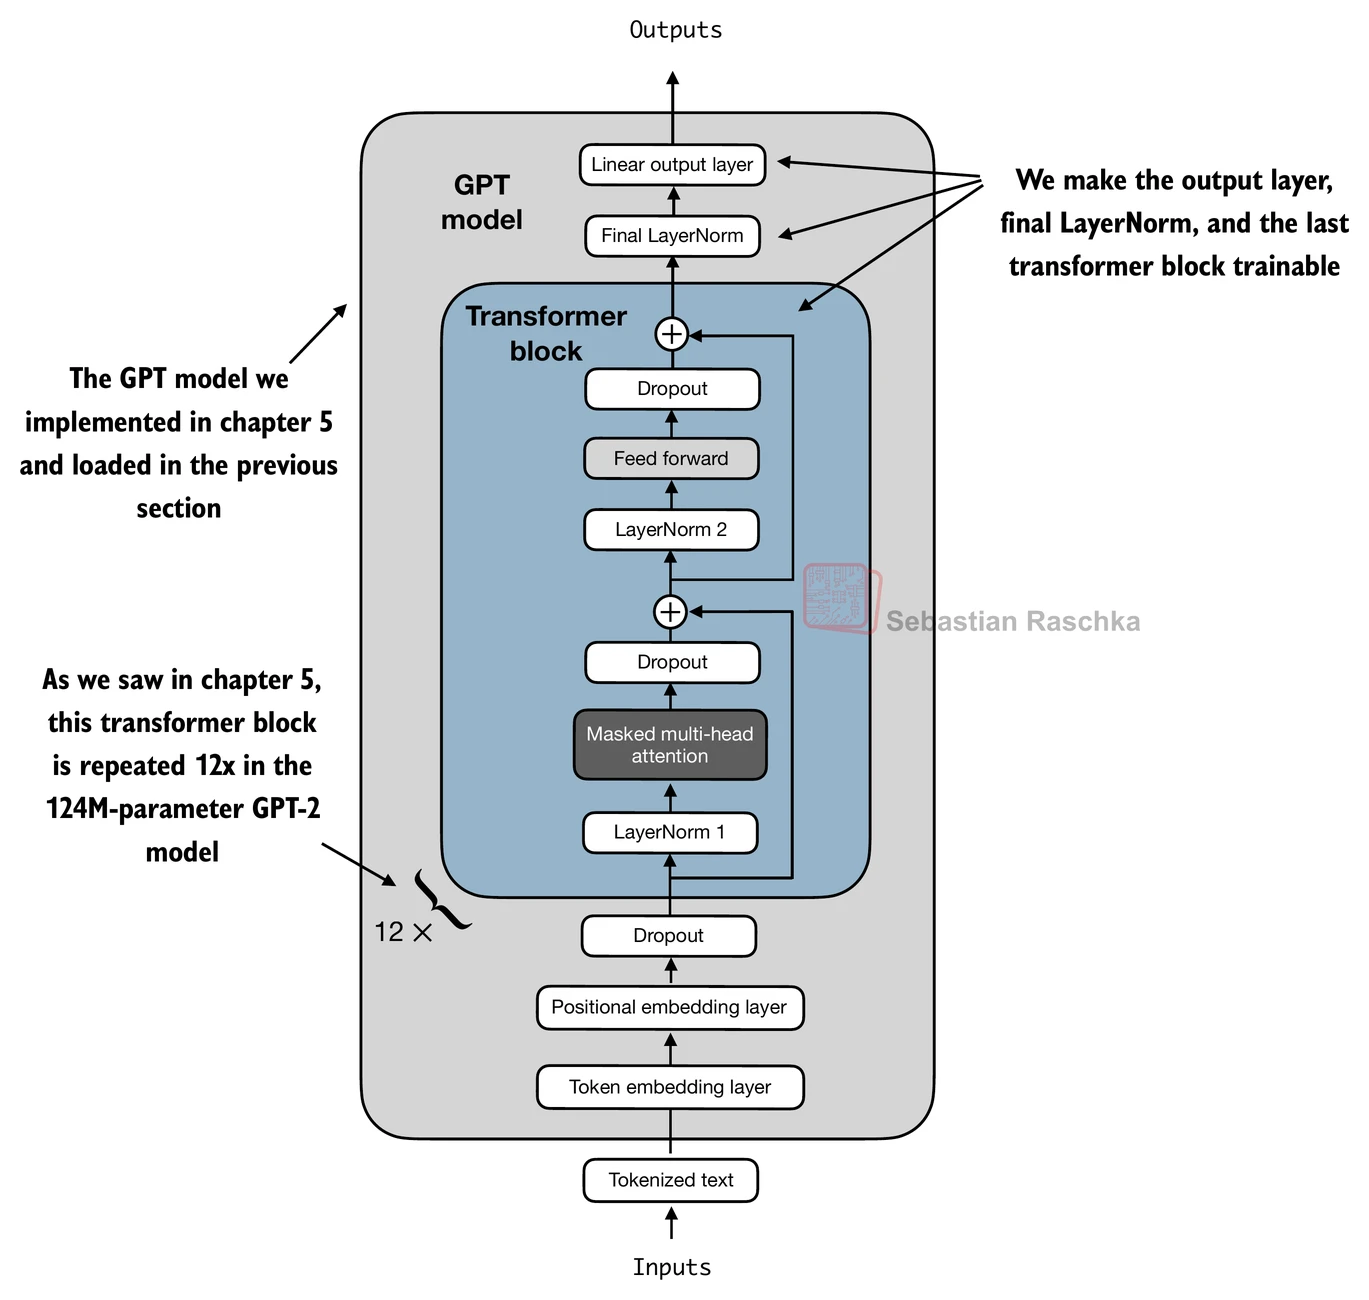
Summary of what is trainable : 
- currently output layer
- need to unfreeze final LayerNorm and last transformer block 

In [28]:
#unfreeze 
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

lets check if it changed 

In [29]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0) #add batch dimension
print("Inputs: ", inputs)
print("Input dimensions:", inputs.shape) #1 sentence with 4 tokens 

Inputs:  tensor([[5211,  345,  423,  640]])
Input dimensions: torch.Size([1, 4])


In [30]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs: \n", outputs)
print("Output dimensions:", outputs.shape) #1 sample with 2 outputs (ham or spam)

Outputs: 
 tensor([[[-1.5883,  0.9920],
         [-3.7208,  7.4510],
         [-2.2642,  6.6005],
         [-3.5965,  3.9889]]])
Output dimensions: torch.Size([1, 4, 2])


Yes, the output has changed for each of the 4 tokens it has 2 outputs 

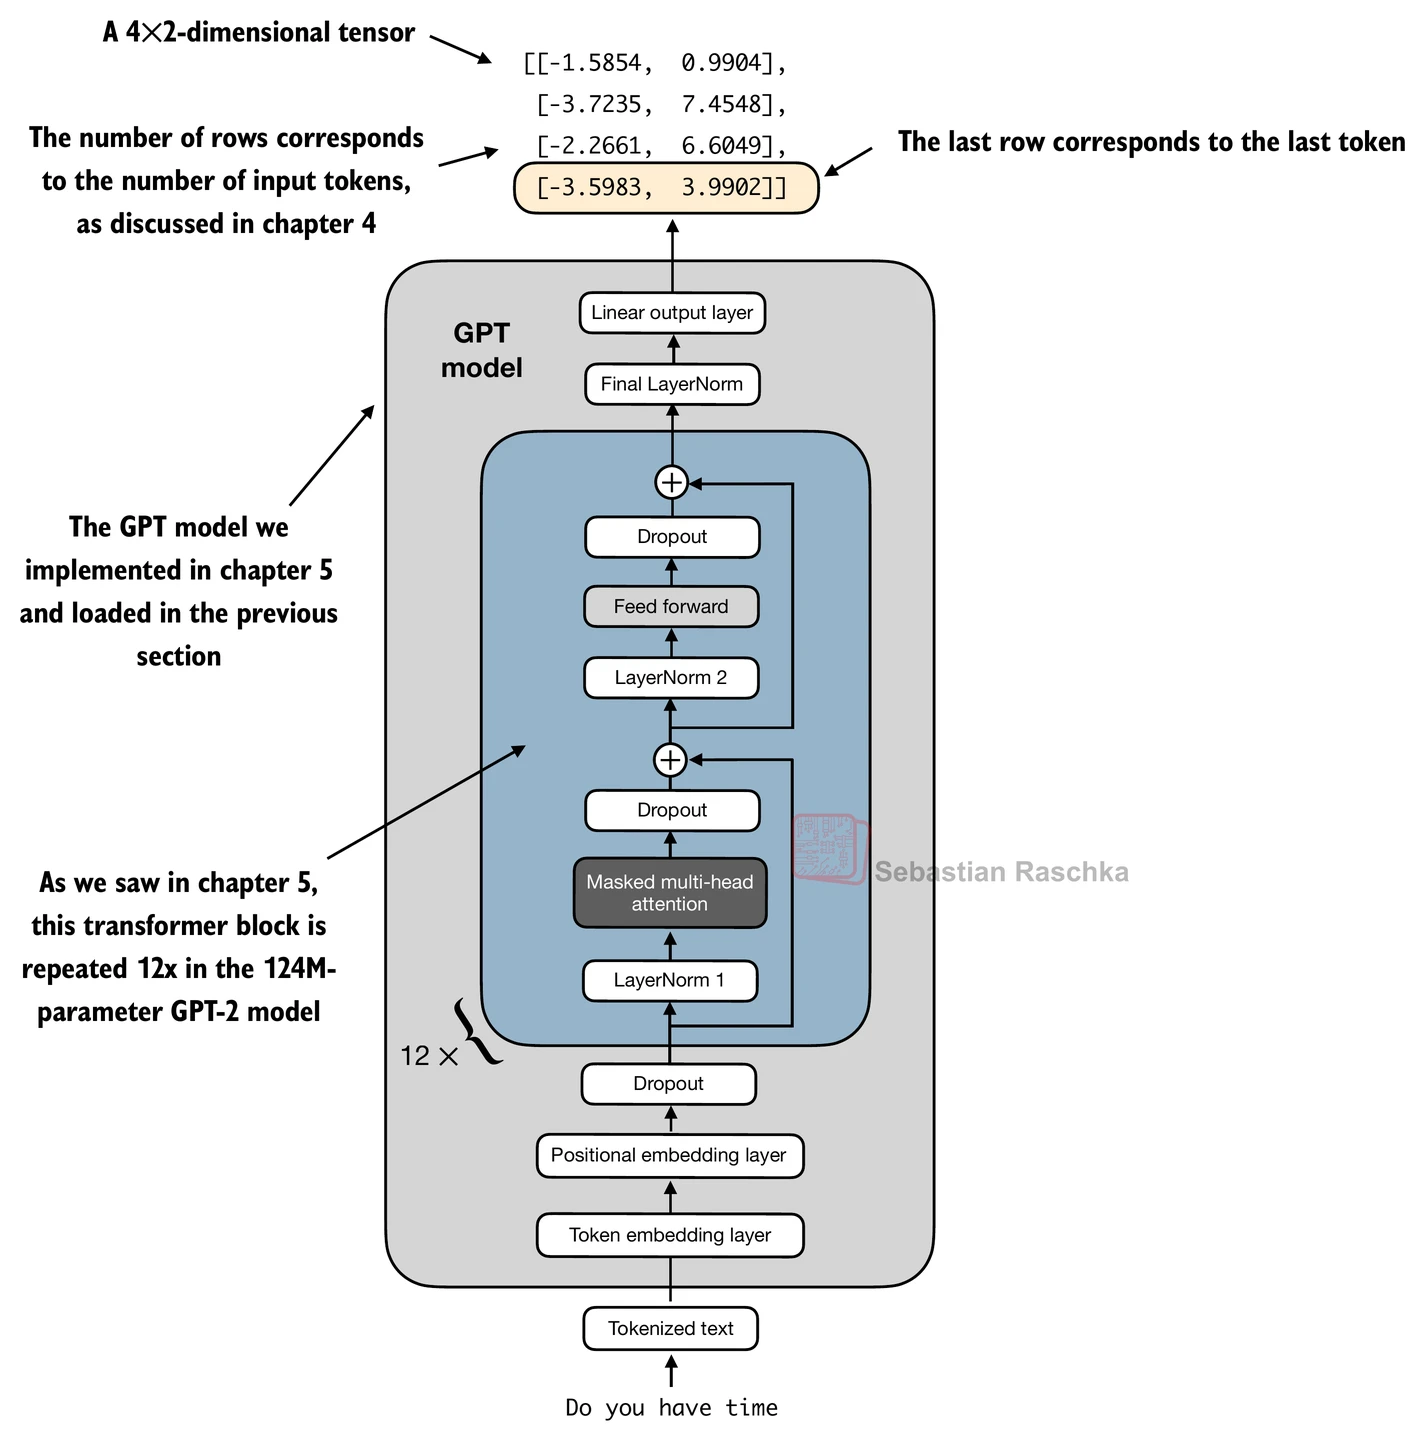
As mentioned each input token is attached to its output and plug into the next meaning we can jut fine tune the last token as it has already processed the entire sentence and includes info about all the previous tokens 

In [31]:
print("Last output token: ", outputs[:, -1, :])

Last output token:  tensor([[-3.5965,  3.9889]])


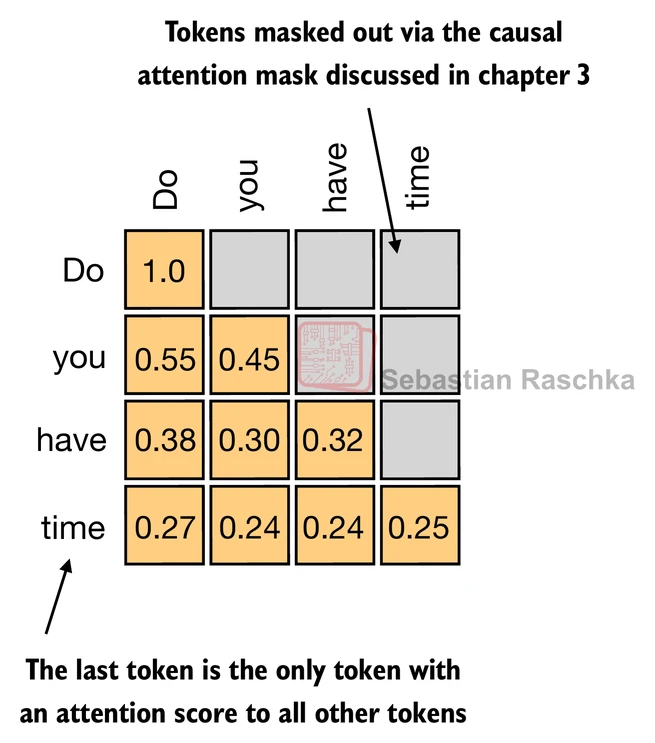 it has all the other attention scores 